# Laboratorio 12: Exploratory Data Analysis (EDA) y Tratamiento de Datos
**Objetivo:** Realizar un análisis exploratorio de datos utilizando Python, aplicando técnicas de análisis univariado, bivariado, visualización y estadística descriptiva. Además, ejecutar procesos de tratamiento de datos, incluyendo la identificación e imputación de valores faltantes.

---
## 1. Importación de Librerías
En esta sección importamos todas las herramientas necesarias para la manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`, `missingno`) y futuros tratamientos (`sklearn`).

In [13]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias para una salida más limpia

## 2. Carga y Exploración Inicial del Dataset
Según la guía, el primer paso del EDA es cargar los datos y verificar la cantidad de registros, variables, tipos de datos y estadísticas descriptivas básicas.

In [14]:
# Definir el nombre del archivo
file_name = "dataset_accidentes_500.csv"

# Cargar el dataset
df_accidentes = pd.read_csv(file_name, sep=",", header=0, encoding="utf-8")

# Mostrar las primeras 5 filas para verificar la correcta lectura
print(f"El dataset tiene {df_accidentes.shape[0]} filas y {df_accidentes.shape[1]} columnas.\n")
display(df_accidentes.head())

El dataset tiene 500 filas y 7 columnas.



,id,fecha,ciudad,tipo_accidente,heridos,fallecidos,daños_materiales_usd
0,1,2023-01-01,Arequipa,Atropello,NaN,0.0,3566.0
1,2,2023-01-02,Trujillo,Caída,0.0,1.0,3181.0
2,3,2023-01-03,Cusco,Caída,3.0,0.0,729.0
3,4,2023-01-04,Trujillo,Choque,2.0,0.0,369.0
4,5,2023-01-05,Trujillo,Atropello,1.0,NaN,5824.0


In [ ]:
# Revisión de los tipos de datos y valores no nulos
print("--- INFORMACIÓN DEL DATASET ---")
df_accidentes.info()
print("\n")

# Estadísticas descriptivas de las variables numéricas
print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df_accidentes.describe())

## 3. Análisis Univariado
En esta sección analizaremos la distribución individual de nuestras variables
Primero, dividiremos los datos según su naturaleza (numéricas y categóricas)
* Para las **variables numéricas**, utilizaremos histogramas
* Para las **variables categóricas**, utilizaremos tablas de frecuencias y gráficos de barras.

In [ ]:
# División de datos según su naturaleza (excluimos 'id' y 'fecha' para este análisis)
numerical_features = ["heridos", "fallecidos", "daños_materiales_usd"]
categorical_features = ["ciudad", "tipo_accidente"]

# Función para plotear histogramas de variables numéricas
def desc_num_feature(features):
    for feature_name in features:
        fig, ax = plt.subplots(figsize=(10, 4))
        df_accidentes[feature_name].hist(bins=20, edgecolor="b", color="skyblue")
        ax.set_title(f"Distribución de: {feature_name}", size=20)
        plt.show()

print("--- ANÁLISIS UNIVARIADO: VARIABLES NUMÉRICAS ---")
desc_num_feature(numerical_features)

--- ANÁLISIS UNIVARIADO: VARIABLES CATEGÓRICAS ---

Tabla de frecuencias para la variable 'ciudad':


,count,percent
ciudad,,
Arequipa,112,22.4
Lima,109,21.8
Ayacucho,95,19.0
Trujillo,93,18.6
Cusco,91,18.2


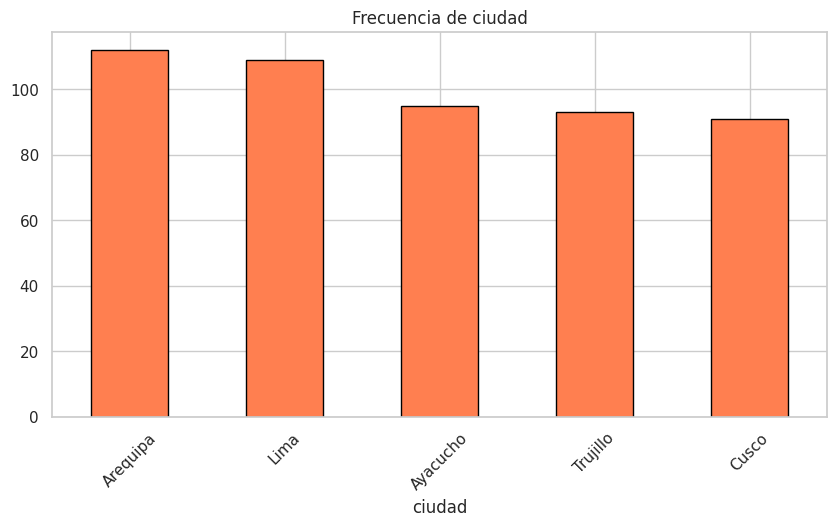


Tabla de frecuencias para la variable 'tipo_accidente':


,count,percent
tipo_accidente,,
Choque,143,28.6
Atropello,125,25.0
Volcadura,124,24.8
Caída,108,21.6


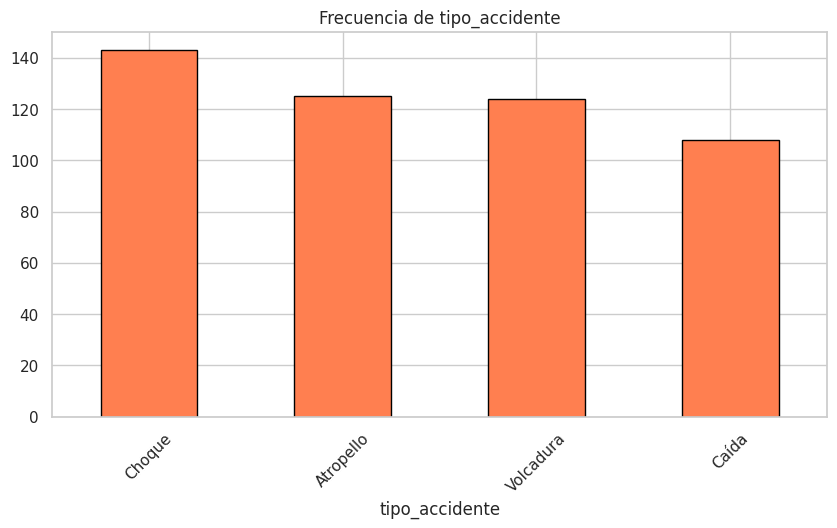

In [17]:
# EDA univariado para variables categóricas
print("--- ANÁLISIS UNIVARIADO: VARIABLES CATEGÓRICAS ---")

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    # Conteo y porcentaje
    count = df_accidentes[feature].value_counts()
    percent = 100 * df_accidentes[feature].value_counts(normalize=True)
    
    # Crear DataFrame resumen
    df_cat = pd.DataFrame({'count': count, 'percent': percent.round(1)})
    print(f"\nTabla de frecuencias para la variable '{feature}':")
    display(df_cat)
    
    # Gráfico de barras
    count.plot(kind='bar', title=f"Frecuencia de {feature}", color="coral", edgecolor="black")
    plt.xticks(rotation=45)
    plt.show()

## 4. Análisis Bivariado
Aquí buscaremos relaciones entre las variables numéricas. 
* Utilizaremos **gráficos de dispersión** para visualizar cómo interactúan pares de variables.
* Calcularemos la **Correlación de Pearson** y mostraremos su respectiva **Matriz de Correlación**
.Valores cercanos a +1 o -1 indican fuerte relación lineal, mientras que valores cercanos a 0 indican ausencia de esta.

--- GRÁFICOS DE DISPERSIÓN ---


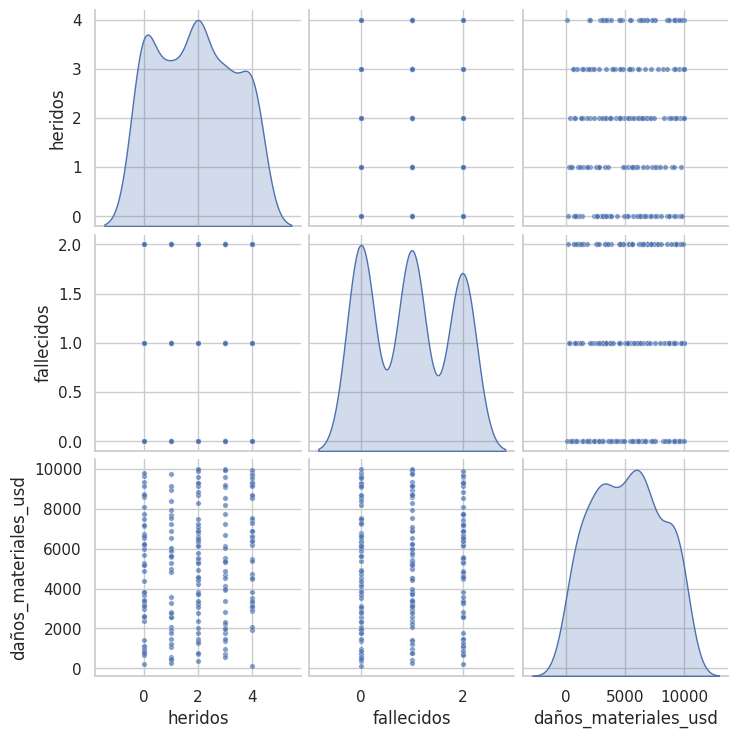


--- MATRIZ DE CORRELACIÓN DE PEARSON ---


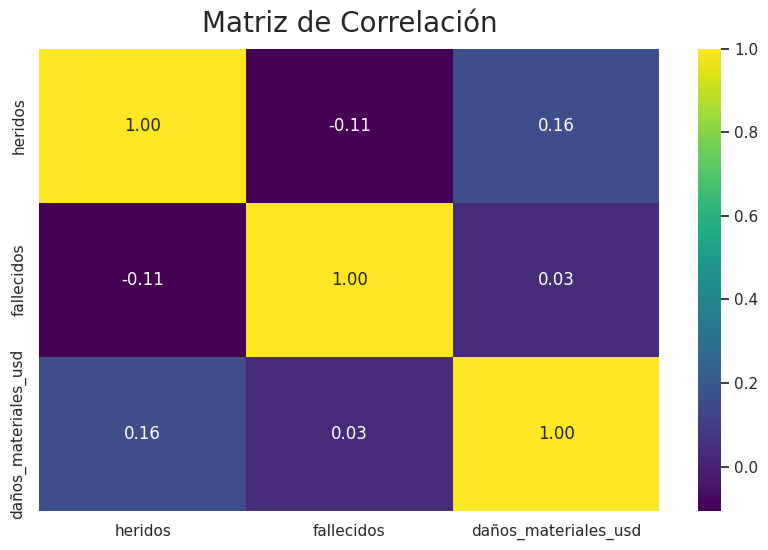

In [22]:
# Gráficos de Dispersión
print("--- GRÁFICOS DE DISPERSIÓN ---")
# Usamos dropna() momentáneamente para que pairplot no falle con los nulos
sns.pairplot(df_accidentes[numerical_features].dropna(), diag_kind='kde', plot_kws={"s": 15, "alpha": 0.7})
plt.show()

# Matriz de Correlación
print("\n--- MATRIZ DE CORRELACIÓN DE PEARSON ---")
plt.figure(figsize=(10, 6))
# Calculamos la correlación numérica
correlacion = df_accidentes[numerical_features].corr()

# Generamos el Heatmap
heatmap = sns.heatmap(correlacion, cmap='viridis', annot=True, fmt=".2f")
heatmap.set_title('Matriz de Correlación', fontdict={'fontsize': 20}, pad=12)
plt.show()

## 5. Identificación y Tratamiento de Valores Faltantes
Antes de entrenar cualquier modelo, debemos tratar los datos perdidos o nulos. En esta sección aplicaremos:
1. **Detección general** de datos perdidos.
2. **Imputación Paramétrica:** Rellenar con la media, mediana o moda.
3. **Imputación No Paramétrica:** Usaremos el algoritmo KNN (K-Nearest Neighbors) para imputar basándonos en similitud.

In [23]:
# 1. Detección de valores nulos
print("--- VALORES NULOS POR COLUMNA ---")
missing_values = df_accidentes.isnull().sum()
print(missing_values[missing_values > 0])
print("\n")

# 2. Imputación Paramétrica 
df_mean = df_accidentes.copy()
df_median = df_accidentes.copy()
df_mode = df_accidentes.copy()

# Imputación con la Media (Útil para variables continuas como los daños materiales)
if 'daños_materiales_usd' in df_mean.columns:
    df_mean["daños_materiales_usd"].fillna(df_mean["daños_materiales_usd"].mean(), inplace=True)

# Imputación con la Mediana (Menos sensible a valores atípicos)
if 'daños_materiales_usd' in df_median.columns:
    df_median["daños_materiales_usd"].fillna(df_median["daños_materiales_usd"].median(), inplace=True)

# Imputación con la Moda (Ideal para valores discretos o categóricos como heridos/fallecidos)
df_mode["heridos"].fillna(df_mode["heridos"].mode()[0], inplace=True)
df_mode["fallecidos"].fillna(df_mode["fallecidos"].mode()[0], inplace=True)

print("Imputación paramétrica completada en dataframes de prueba.")

--- VALORES NULOS POR COLUMNA ---
heridos                 125
fallecidos              125
daños_materiales_usd    125
dtype: int64


Imputación paramétrica completada en dataframes de prueba.


### Imputación No Paramétrica (KNN Imputer)
Según la documentación, `KNNImputer` encuentra los "vecinos" más cercanos utilizando distancia euclidiana y usa sus valores medios para rellenar los nulos. Es un método mucho más robusto que usar promedios simples.

In [ ]:
# 3. Imputación con KNN
from sklearn.impute import KNNImputer

df_knn = df_accidentes.copy()

# Inicializar KNNImputer con 3 vecinos 
imputer = KNNImputer(n_neighbors=3)

# Aplicarlo a nuestras variables numéricas
columnas_num = ["heridos", "fallecidos", "daños_materiales_usd"]
df_knn[columnas_num] = imputer.fit_transform(df_knn[columnas_num]).round(0) # Redondeamos a 0 decimales para heridos/fallecidos

print("--- NULOS DESPUÉS DE KNN IMPUTER ---")
print(df_knn[columnas_num].isnull().sum())

--- NULOS DESPUÉS DE KNN IMPUTER ---
heridos                 0
fallecidos              0
daños_materiales_usd    0
dtype: int64


## 6. Conversión de Datos Categóricos a Numéricos
Los algoritmos de Machine Learning requieren que todas las entradas sean numéricas. Transformaremos nuestras variables de texto (`ciudad`, `tipo_accidente`) usando técnicas estándar.
* **One Hot Encoding:** Crea vectores binarios (columnas Dummies) para cada categoría.
* **Label Encoding:** Asigna un número entero único a cada categoría.

In [21]:
# 1. One Hot Encoding con Pandas
# Esta técnica es ideal para variables sin un orden jerárquico (ej. tipo_accidente)
print("--- ONE HOT ENCODING (tipo_accidente) ---")
# Usamos drop_first=True para evitar la trampa de las variables ficticias (colinealidad)
df_codificado = pd.get_dummies(df_knn, columns=["tipo_accidente"], drop_first=True)
display(df_codificado.head(3))

print("\n")

# 2. Label Encoding con Scikit-Learn
# Convierte cada valor de la columna en un número entero simple
from sklearn.preprocessing import LabelEncoder

print("--- LABEL ENCODING (ciudad) ---")
le = LabelEncoder()
df_codificado["ciudad_encoded"] = le.fit_transform(df_codificado["ciudad"])

# Mostramos el mapeo de cómo quedó
display(df_codificado[["ciudad", "ciudad_encoded"]].head())

--- ONE HOT ENCODING (tipo_accidente) ---


,id,fecha,ciudad,heridos,fallecidos,daños_materiales_usd,tipo_accidente_Caída,tipo_accidente_Choque,tipo_accidente_Volcadura
0,1,2023-01-01,Arequipa,3.0,0.0,3566.0,False,False,False
1,2,2023-01-02,Trujillo,0.0,1.0,3181.0,True,False,False
2,3,2023-01-03,Cusco,3.0,0.0,729.0,True,False,False




--- LABEL ENCODING (ciudad) ---


,ciudad,ciudad_encoded
0,Arequipa,0
1,Trujillo,4
2,Cusco,2
3,Trujillo,4
4,Trujillo,4
